# Impairment Robustness Evaluation

This notebook evaluates model robustness under various hardware impairments:
- Carrier Frequency Offset (CFO)
- I/Q Imbalance
- Phase Noise
- Fading channels (Rayleigh, Rician)

Uses TorchSig for controlled impairment evaluation.

In [27]:
import sys
from pathlib import Path

src_path = Path("../src")
if src_path.exists():
    sys.path.insert(0, str(src_path.resolve()))

import matplotlib.pyplot as plt
import numpy as np
import torch
from tqdm.auto import tqdm

from robust_amc.data import (
    Compose,
    PowerNormalize,
    get_loaders,
    load_config_from_yaml,
)
from robust_amc.data.channels import RayleighFading, RicianFading
from robust_amc.data.impairments import (
    CarrierFrequencyOffset,
    IQImbalance,
    PhaseNoise,
)
from robust_amc.data.transforms import ToTensor  # noqa: E402
from robust_amc.models import create_pfcnn, create_clsr_amc
from robust_amc.utils import get_device


## 1. Setup

In [41]:
model_type = "pfcnn"
if model_type == "pfcnn":
    CHECKPOINT_PATH = Path("../checkpoints/pfcnn-large/best_model.pt")
elif model_type == "pfcnn-aug":
    CHECKPOINT_PATH = Path("../checkpoints/pfcnn-large-augment/best_model.pt")
else:
    CHECKPOINT_PATH = Path("../checkpoints/clsr_amc-large/best_model.pt")
CONFIG_PATH = Path("../configs/datasets/torchsig_train.yaml")

device = get_device("auto")
print(f"Using device: {device} - Model {model_type}")

Using device: mps - Model pfcnn


In [ ]:
# Load model
if not CHECKPOINT_PATH.exists():
    print(f"Checkpoint not found at {CHECKPOINT_PATH}")
    print("Run: uv run python scripts/train_pfcnn.py")
    model = None
else:
    if model_type == "pfcnn" or model_type == "pfcnn-aug":
        model = create_pfcnn(num_classes=5, variant="large")  # 5 families
    else:
        model = create_clsr_amc(num_classes=5, variant="large", seq_len=1024)

    ckpt = torch.load(CHECKPOINT_PATH, map_location="cpu", weights_only=False)
    model.load_state_dict(ckpt["model_state_dict"])
    model.eval()
    model = model.to(device)
    print("Model loaded successfully!")

Model loaded successfully!


In [43]:
# Load test data
config = load_config_from_yaml(CONFIG_PATH)
config.label_map_path = "".join(["../", config.label_map_path])
config.data_path = "".join(["../", config.data_path])
loaders = get_loaders(config)
family_names = loaders["family_names"]
print(f"Test set: {len(loaders['test'].dataset)} samples")
print(f"Families: {family_names}")

Test set: 56000 samples
Families: ['PSK', 'FSK', 'AM', 'SSB', 'QAM']


## 2. Evaluation Utilities

In [9]:
def evaluate_with_impairment(model, loader, impairment_fn, device, max_samples=1000):
    """Evaluate model accuracy with an impairment applied."""
    if model is None:
        return 0.0

    model.eval()
    correct = 0
    total = 0

    normalize = PowerNormalize()
    to_tensor = ToTensor()

    with torch.no_grad():
        for batch in loader:
            x, y, meta = batch

            # Apply impairment to each sample
            x_impaired = []
            for i in range(len(x)):
                sample = x[i].numpy() if isinstance(x[i], torch.Tensor) else x[i]
                if impairment_fn is not None:
                    sample = impairment_fn(sample)
                sample = normalize(sample)
                sample = to_tensor(sample)
                x_impaired.append(sample)

            x_impaired = torch.stack(x_impaired).to(device)
            y = y.to(device)

            outputs = model(x_impaired)
            preds = outputs.argmax(dim=1)
            correct += (preds == y).sum().item()
            total += len(y)

            if total >= max_samples:
                break

    return correct / total if total > 0 else 0.0

## 3. CFO Sweep

In [44]:
cfo_values = [0, 500, 1000, 1500, 2000, 2500, 3000, 4000, 5000]
cfo_accuracies = []

for cfo_hz in tqdm(cfo_values, desc="CFO Sweep"):
    if cfo_hz == 0:
        impairment = None
    else:
        impairment = CarrierFrequencyOffset(delta_f=cfo_hz, sample_rate=1e6)

    acc = evaluate_with_impairment(model, loaders["test"], impairment, device)
    cfo_accuracies.append(acc)
    print(f"  CFO={cfo_hz} Hz: {acc:.2%}")

CFO Sweep:   0%|          | 0/9 [00:00<?, ?it/s]

/Users/ygglc/Work/Projects/CDT/modulation-classification/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
0.00s - Debugger warning: It seems that frozen modules are being used, which may
0.00s - make the debugger miss breakpoints. Please pass -Xfrozen_modules=off
0.00s - to python to disable frozen modules.
0.00s - Note: Debugging will proceed. Set PYDEVD_DISABLE_FILE_VALIDATION=1 to disable this validation.
0.00s - Debugger warning: It seems that frozen modules are being used, which may
0.00s - make the debugger miss breakpoints. Please pass -Xfrozen_modules=off
0.00s - to python to disable frozen modules.
0.00s - Note: Debugging will proceed. Set PYDEVD_DISABLE_FILE_VALIDATION=1 to disable this validation.
0.00s - Debugger warning: It seems that frozen modules are being used, which may
0.00s - make the debugger miss brea

  CFO=0 Hz: 61.04%


0.00s - Debugger warning: It seems that frozen modules are being used, which may
0.00s - make the debugger miss breakpoints. Please pass -Xfrozen_modules=off
0.00s - to python to disable frozen modules.
0.00s - Note: Debugging will proceed. Set PYDEVD_DISABLE_FILE_VALIDATION=1 to disable this validation.
0.00s - Debugger warning: It seems that frozen modules are being used, which may
0.00s - make the debugger miss breakpoints. Please pass -Xfrozen_modules=off
0.00s - to python to disable frozen modules.
0.00s - Note: Debugging will proceed. Set PYDEVD_DISABLE_FILE_VALIDATION=1 to disable this validation.
0.00s - Debugger warning: It seems that frozen modules are being used, which may
0.00s - make the debugger miss breakpoints. Please pass -Xfrozen_modules=off
0.00s - to python to disable frozen modules.
0.00s - Note: Debugging will proceed. Set PYDEVD_DISABLE_FILE_VALIDATION=1 to disable this validation.
0.00s - Debugger warning: It seems that frozen modules are being used, which may
0

  CFO=500 Hz: 59.57%


...

  CFO=3000 Hz: 59.96%


0.00s - Debugger warning: It seems that frozen modules are being used, which may
0.00s - make the debugger miss breakpoints. Please pass -Xfrozen_modules=off
0.00s - to python to disable frozen modules.
0.00s - Note: Debugging will proceed. Set PYDEVD_DISABLE_FILE_VALIDATION=1 to disable this validation.
0.00s - Debugger warning: It seems that frozen modules are being used, which may
0.00s - make the debugger miss breakpoints. Please pass -Xfrozen_modules=off
0.00s - to python to disable frozen modules.
0.00s - Note: Debugging will proceed. Set PYDEVD_DISABLE_FILE_VALIDATION=1 to disable this validation.
0.00s - Debugger warning: It seems that frozen modules are being used, which may
0.00s - make the debugger miss breakpoints. Please pass -Xfrozen_modules=off
0.00s - to python to disable frozen modules.
0.00s - Note: Debugging will proceed. Set PYDEVD_DISABLE_FILE_VALIDATION=1 to disable this validation.
0.00s - Debugger warning: It seems that frozen modules are being used, which may
0

  CFO=4000 Hz: 59.86%


0.00s - Debugger warning: It seems that frozen modules are being used, which may
0.00s - make the debugger miss breakpoints. Please pass -Xfrozen_modules=off
0.00s - to python to disable frozen modules.
0.00s - Note: Debugging will proceed. Set PYDEVD_DISABLE_FILE_VALIDATION=1 to disable this validation.
0.00s - Debugger warning: It seems that frozen modules are being used, which may
0.00s - make the debugger miss breakpoints. Please pass -Xfrozen_modules=off
0.00s - to python to disable frozen modules.
0.00s - Note: Debugging will proceed. Set PYDEVD_DISABLE_FILE_VALIDATION=1 to disable this validation.
0.00s - Debugger warning: It seems that frozen modules are being used, which may
0.00s - make the debugger miss breakpoints. Please pass -Xfrozen_modules=off
0.00s - to python to disable frozen modules.
0.00s - Note: Debugging will proceed. Set PYDEVD_DISABLE_FILE_VALIDATION=1 to disable this validation.
0.00s - Debugger warning: It seems that frozen modules are being used, which may
0

  CFO=5000 Hz: 60.25%


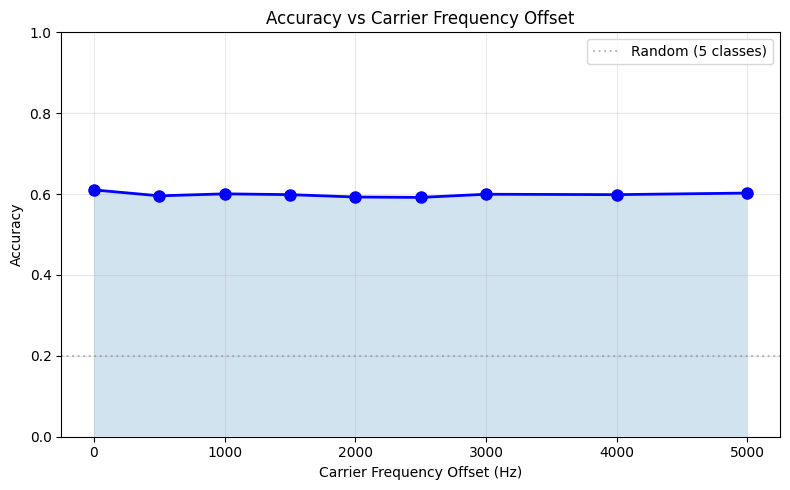

In [45]:
plt.figure(figsize=(8, 5))
plt.plot(cfo_values, cfo_accuracies, "b-o", linewidth=2, markersize=8)
plt.fill_between(cfo_values, cfo_accuracies, alpha=0.2)
plt.xlabel("Carrier Frequency Offset (Hz)")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Carrier Frequency Offset")
plt.grid(True, alpha=0.3)
plt.ylim(0, 1)
plt.axhline(y=0.2, color='gray', linestyle=':', alpha=0.5, label='Random (5 classes)')
plt.legend()
plt.tight_layout()
plt.show()

## 4. I/Q Imbalance Sweep

In [46]:
# Amplitude imbalance
amp_values = [0, 0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 4.0]
amp_accuracies = []

for amp_db in tqdm(amp_values, desc="Amplitude Imbalance"):
    if amp_db == 0:
        impairment = None
    else:
        impairment = IQImbalance(amplitude_imbalance_db=amp_db, phase_imbalance_deg=0)
    
    acc = evaluate_with_impairment(model, loaders["test"], impairment, device)
    amp_accuracies.append(acc)

Amplitude Imbalance:   0%|          | 0/8 [00:00<?, ?it/s]

/Users/ygglc/Work/Projects/CDT/modulation-classification/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
0.00s - Debugger warning: It seems that frozen modules are being used, which may
0.00s - make the debugger miss breakpoints. Please pass -Xfrozen_modules=off
0.00s - to python to disable frozen modules.
0.00s - Note: Debugging will proceed. Set PYDEVD_DISABLE_FILE_VALIDATION=1 to disable this validation.
0.00s - Debugger warning: It seems that frozen modules are being used, which may
0.00s - make the debugger miss breakpoints. Please pass -Xfrozen_modules=off
0.00s - to python to disable frozen modules.
0.00s - Note: Debugging will proceed. Set PYDEVD_DISABLE_FILE_VALIDATION=1 to disable this validation.
0.00s - Debugger warning: It seems that frozen modules are being used, which may
0.00s - make the debugger miss brea

In [13]:
# Phase imbalance
phase_values = [0, 2, 5, 8, 10, 12, 15, 20]
phase_accuracies = []

for phase_deg in tqdm(phase_values, desc="Phase Imbalance"):
    if phase_deg == 0:
        impairment = None
    else:
        impairment = IQImbalance(amplitude_imbalance_db=0, phase_imbalance_deg=phase_deg)
    
    acc = evaluate_with_impairment(model, loaders["test"], impairment, device)
    phase_accuracies.append(acc)

Phase Imbalance:   0%|          | 0/8 [00:00<?, ?it/s]

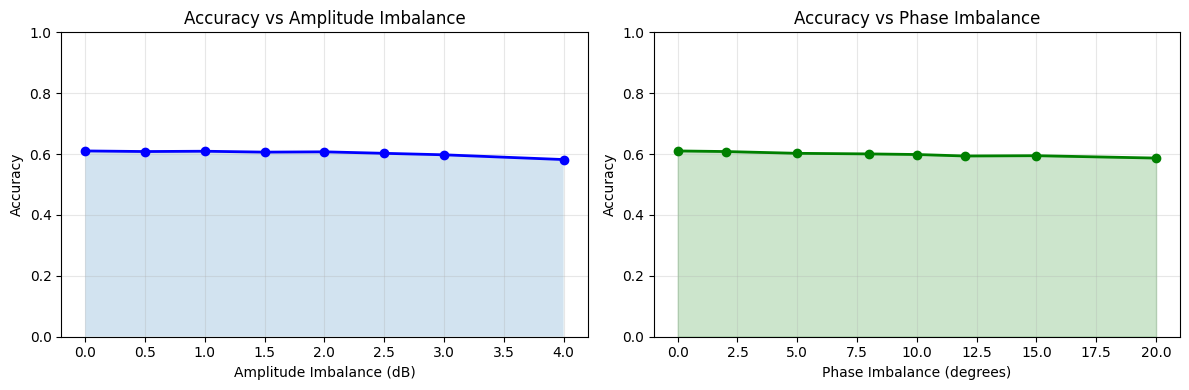

In [47]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(amp_values, amp_accuracies, "b-o", linewidth=2)
axes[0].fill_between(amp_values, amp_accuracies, alpha=0.2)
axes[0].set_xlabel("Amplitude Imbalance (dB)")
axes[0].set_ylabel("Accuracy")
axes[0].set_title("Accuracy vs Amplitude Imbalance")
axes[0].grid(True, alpha=0.3)
axes[0].set_ylim(0, 1)

axes[1].plot(phase_values, phase_accuracies, "g-o", linewidth=2)
axes[1].fill_between(phase_values, phase_accuracies, alpha=0.2, color='green')
axes[1].set_xlabel("Phase Imbalance (degrees)")
axes[1].set_ylabel("Accuracy")
axes[1].set_title("Accuracy vs Phase Imbalance")
axes[1].grid(True, alpha=0.3)
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.show()

## 5. Phase Noise Sweep

In [48]:
pn_values = [0, 0.01, 0.02, 0.03, 0.04, 0.05, 0.08, 0.1]
pn_accuracies = []

for pn_std in tqdm(pn_values, desc="Phase Noise"):
    if pn_std == 0:
        impairment = None
    else:
        impairment = PhaseNoise(std_per_sample=pn_std)
    
    acc = evaluate_with_impairment(model, loaders["test"], impairment, device)
    pn_accuracies.append(acc)
    print(f"  Phase noise={pn_std:.3f} rad/sample: {acc:.2%}")

Phase Noise:   0%|          | 0/8 [00:00<?, ?it/s]

0.00s - Debugger warning: It seems that frozen modules are being used, which may
0.00s - make the debugger miss breakpoints. Please pass -Xfrozen_modules=off
0.00s - to python to disable frozen modules.
0.00s - Note: Debugging will proceed. Set PYDEVD_DISABLE_FILE_VALIDATION=1 to disable this validation.
0.00s - Debugger warning: It seems that frozen modules are being used, which may
0.00s - make the debugger miss breakpoints. Please pass -Xfrozen_modules=off
0.00s - to python to disable frozen modules.
0.00s - Note: Debugging will proceed. Set PYDEVD_DISABLE_FILE_VALIDATION=1 to disable this validation.
0.00s - Debugger warning: It seems that frozen modules are being used, which may
0.00s - make the debugger miss breakpoints. Please pass -Xfrozen_modules=off
0.00s - to python to disable frozen modules.
0.00s - Note: Debugging will proceed. Set PYDEVD_DISABLE_FILE_VALIDATION=1 to disable this validation.
0.00s - Debugger warning: It seems that frozen modules are being used, which may
0

  Phase noise=0.000 rad/sample: 61.04%


0.00s - Debugger warning: It seems that frozen modules are being used, which may
0.00s - make the debugger miss breakpoints. Please pass -Xfrozen_modules=off
0.00s - to python to disable frozen modules.
0.00s - Note: Debugging will proceed. Set PYDEVD_DISABLE_FILE_VALIDATION=1 to disable this validation.
0.00s - Debugger warning: It seems that frozen modules are being used, which may
0.00s - make the debugger miss breakpoints. Please pass -Xfrozen_modules=off
0.00s - to python to disable frozen modules.
0.00s - Note: Debugging will proceed. Set PYDEVD_DISABLE_FILE_VALIDATION=1 to disable this validation.
0.00s - Debugger warning: It seems that frozen modules are being used, which may
0.00s - make the debugger miss breakpoints. Please pass -Xfrozen_modules=off
0.00s - to python to disable frozen modules.
0.00s - Note: Debugging will proceed. Set PYDEVD_DISABLE_FILE_VALIDATION=1 to disable this validation.
0.00s - Debugger warning: It seems that frozen modules are being used, which may
0

  Phase noise=0.010 rad/sample: 60.35%


...

  Phase noise=0.050 rad/sample: 59.96%


0.00s - Debugger warning: It seems that frozen modules are being used, which may
0.00s - make the debugger miss breakpoints. Please pass -Xfrozen_modules=off
0.00s - to python to disable frozen modules.
0.00s - Note: Debugging will proceed. Set PYDEVD_DISABLE_FILE_VALIDATION=1 to disable this validation.
0.00s - Debugger warning: It seems that frozen modules are being used, which may
0.00s - make the debugger miss breakpoints. Please pass -Xfrozen_modules=off
0.00s - to python to disable frozen modules.
0.00s - Note: Debugging will proceed. Set PYDEVD_DISABLE_FILE_VALIDATION=1 to disable this validation.
0.00s - Debugger warning: It seems that frozen modules are being used, which may
0.00s - make the debugger miss breakpoints. Please pass -Xfrozen_modules=off
0.00s - to python to disable frozen modules.
0.00s - Note: Debugging will proceed. Set PYDEVD_DISABLE_FILE_VALIDATION=1 to disable this validation.
0.00s - Debugger warning: It seems that frozen modules are being used, which may
0

  Phase noise=0.080 rad/sample: 60.25%


0.00s - Debugger warning: It seems that frozen modules are being used, which may
0.00s - make the debugger miss breakpoints. Please pass -Xfrozen_modules=off
0.00s - to python to disable frozen modules.
0.00s - Note: Debugging will proceed. Set PYDEVD_DISABLE_FILE_VALIDATION=1 to disable this validation.
0.00s - Debugger warning: It seems that frozen modules are being used, which may
0.00s - make the debugger miss breakpoints. Please pass -Xfrozen_modules=off
0.00s - to python to disable frozen modules.
0.00s - Note: Debugging will proceed. Set PYDEVD_DISABLE_FILE_VALIDATION=1 to disable this validation.
0.00s - Debugger warning: It seems that frozen modules are being used, which may
0.00s - make the debugger miss breakpoints. Please pass -Xfrozen_modules=off
0.00s - to python to disable frozen modules.
0.00s - Note: Debugging will proceed. Set PYDEVD_DISABLE_FILE_VALIDATION=1 to disable this validation.
0.00s - Debugger warning: It seems that frozen modules are being used, which may
0

  Phase noise=0.100 rad/sample: 59.67%


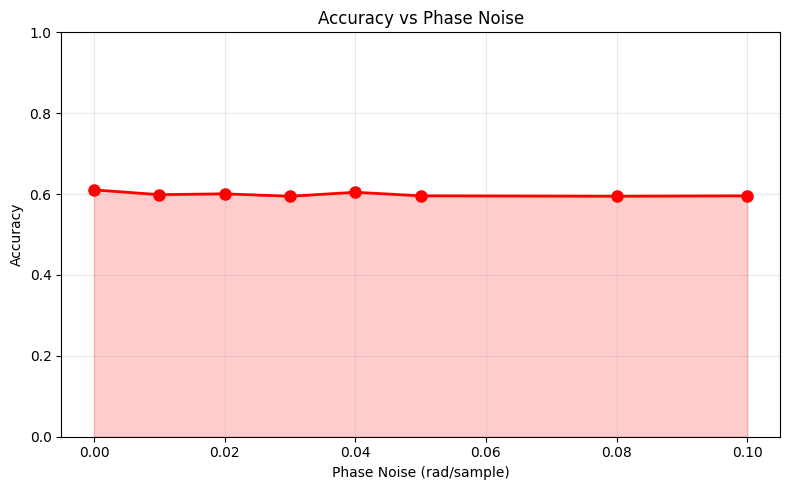

In [16]:
plt.figure(figsize=(8, 5))
plt.plot(pn_values, pn_accuracies, "r-o", linewidth=2, markersize=8)
plt.fill_between(pn_values, pn_accuracies, alpha=0.2, color='red')
plt.xlabel("Phase Noise (rad/sample)")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Phase Noise")
plt.grid(True, alpha=0.3)
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

## 6. Fading Channel Evaluation

In [17]:
# Baseline (no fading)
baseline_acc = evaluate_with_impairment(model, loaders["test"], None, device)
print(f"Baseline (no fading): {baseline_acc:.2%}")

# Rayleigh fading
rayleigh_acc = evaluate_with_impairment(model, loaders["test"], RayleighFading(), device)
print(f"Rayleigh fading: {rayleigh_acc:.2%}")

# Rician fading with different K-factors
k_factors = [0.5, 1, 2, 5, 10]
rician_accuracies = []

for k in tqdm(k_factors, desc="Rician K-factors"):
    acc = evaluate_with_impairment(model, loaders["test"], RicianFading(k_factor=k), device)
    rician_accuracies.append(acc)
    print(f"  Rician K={k}: {acc:.2%}")

Baseline (no fading): 61.04%
Rayleigh fading: 59.67%


Rician K-factors:   0%|          | 0/5 [00:00<?, ?it/s]

  Rician K=0.5: 59.67%
  Rician K=1: 60.25%
  Rician K=2: 59.57%
  Rician K=5: 59.96%
  Rician K=10: 60.16%


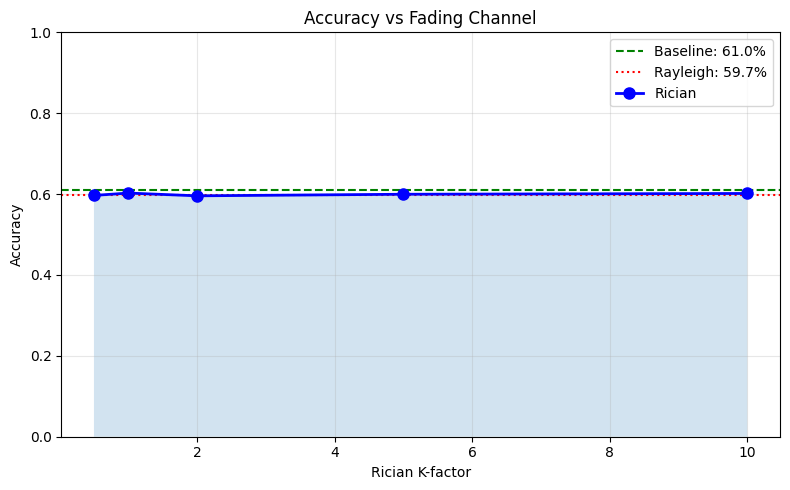

In [18]:
fig, ax = plt.subplots(figsize=(8, 5))

# Plot baseline and Rayleigh as reference lines
ax.axhline(y=baseline_acc, color='green', linestyle='--', label=f'Baseline: {baseline_acc:.1%}')
ax.axhline(y=rayleigh_acc, color='red', linestyle=':', label=f'Rayleigh: {rayleigh_acc:.1%}')

# Plot Rician vs K-factor
ax.plot(k_factors, rician_accuracies, 'b-o', linewidth=2, markersize=8, label='Rician')
ax.fill_between(k_factors, rician_accuracies, alpha=0.2)

ax.set_xlabel("Rician K-factor")
ax.set_ylabel("Accuracy")
ax.set_title("Accuracy vs Fading Channel")
ax.grid(True, alpha=0.3)
ax.set_ylim(0, 1)
ax.legend()
plt.tight_layout()
plt.show()

## 7. Summary

Collect all results and compute the **domain gap** (baseline vs worst case).

In [40]:
print("=" * 50)
print("Impairment Robustness Summary")
print("=" * 50)

print(f"\nBaseline (clean): {baseline_acc:.2%}")
print(f"\nCFO:")
print(f"  0 Hz: {cfo_accuracies[0]:.2%}")
print(f"  5000 Hz: {cfo_accuracies[-1]:.2%}")
print(f"  Gap: {cfo_accuracies[0] - cfo_accuracies[-1]:.2%}")

print(f"\nI/Q Imbalance:")
print(f"  Amp 0 dB: {amp_accuracies[0]:.2%}")
print(f"  Amp 4 dB: {amp_accuracies[-1]:.2%}")
print(f"  Phase 0°: {phase_accuracies[0]:.2%}")
print(f"  Phase 20°: {phase_accuracies[-1]:.2%}")

print(f"\nPhase Noise:")
print(f"  0 rad/s: {pn_accuracies[0]:.2%}")
print(f"  0.1 rad/s: {pn_accuracies[-1]:.2%}")
print(f"  Gap: {pn_accuracies[0] - pn_accuracies[-1]:.2%}")

print(f"\nFading:")
print(f"  Rayleigh: {rayleigh_acc:.2%}")
print(f"  Gap from baseline: {baseline_acc - rayleigh_acc:.2%}")

# Overall worst case
all_accuracies = cfo_accuracies + amp_accuracies + phase_accuracies + pn_accuracies + [rayleigh_acc]
worst_acc = min(all_accuracies)
print(f"\n" + "=" * 50)
print(f"Overall Domain Gap: {baseline_acc - worst_acc:.2%}")
print(f"Worst case accuracy: {worst_acc:.2%}")

Impairment Robustness Summary

Baseline (clean): 61.04%

CFO:
  0 Hz: 64.75%
  5000 Hz: 64.45%
  Gap: 0.29%

I/Q Imbalance:
  Amp 0 dB: 64.75%
  Amp 4 dB: 63.28%
  Phase 0°: 61.04%
  Phase 20°: 58.69%

Phase Noise:
  0 rad/s: 61.04%
  0.1 rad/s: 59.57%
  Gap: 1.46%

Fading:
  Rayleigh: 59.67%
  Gap from baseline: 1.37%

Overall Domain Gap: 2.34%
Worst case accuracy: 58.69%
